#Rozpoznawanie Płci na Podstawie Cech Głosu (Model k-NN)

Celem tego projektu jest zbudowanie optymalnego modelu klasyfikacyjnego k-Najbliższych Sąsiadów (k-NN) do przewidywania płci (zmienna `label`) na podstawie właściwości akustycznych głosu.

**Zbiór danych:** `voice.csv` zawiera pomiary akustyczne przetworzonych nagrań głosów męskich i żeńskich.

## 1. Eksploracyjna Analiza Danych
Sprawdzamy podstawowe informacje o zbiorze, braki danych oraz balans klas zmiennej docelowej.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#voice = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/voice.csv') # Zmień to na:
voice = pd.read_csv('data/voice.csv')
voice

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,0.131884,0.084734,0.153707,0.049285,0.201144,0.151859,1.762129,6.630383,0.962934,0.763182,...,0.131884,0.182790,0.083770,0.262295,0.832899,0.007812,4.210938,4.203125,0.161929,female
3164,0.116221,0.089221,0.076758,0.042718,0.204911,0.162193,0.693730,2.503954,0.960716,0.709570,...,0.116221,0.188980,0.034409,0.275862,0.909856,0.039062,3.679688,3.640625,0.277897,female
3165,0.142056,0.095798,0.183731,0.033424,0.224360,0.190936,1.876502,6.604509,0.946854,0.654196,...,0.142056,0.209918,0.039506,0.275862,0.494271,0.007812,2.937500,2.929688,0.194759,female
3166,0.143659,0.090628,0.184976,0.043508,0.219943,0.176435,1.591065,5.388298,0.950436,0.675470,...,0.143659,0.172375,0.034483,0.250000,0.791360,0.007812,3.593750,3.585938,0.311002,female


In [7]:
voice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

In [8]:
#Zmienna celu
voice.label.value_counts()

,count
label,
male,1584
female,1584


In [9]:
voice.label.value_counts(normalize=True)

,proportion
label,
male,0.5
female,0.5


<Axes: xlabel='label', ylabel='count'>

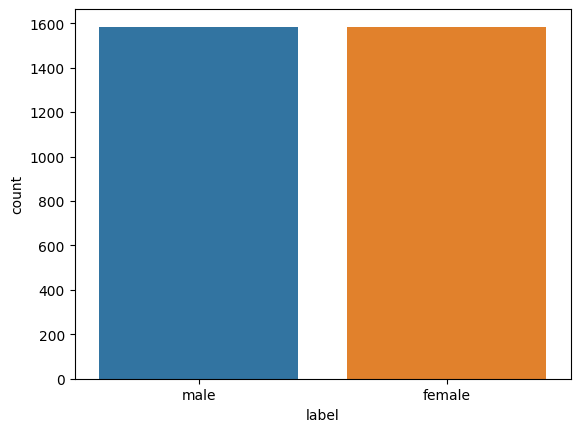

In [10]:
sns.countplot(x= "label",data = voice, hue="label")

In [11]:
x = voice[voice.columns[:20]]
y = voice.label

In [12]:
x

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3163,0.131884,0.084734,0.153707,0.049285,0.201144,0.151859,1.762129,6.630383,0.962934,0.763182,0.200836,0.131884,0.182790,0.083770,0.262295,0.832899,0.007812,4.210938,4.203125,0.161929
3164,0.116221,0.089221,0.076758,0.042718,0.204911,0.162193,0.693730,2.503954,0.960716,0.709570,0.013683,0.116221,0.188980,0.034409,0.275862,0.909856,0.039062,3.679688,3.640625,0.277897
3165,0.142056,0.095798,0.183731,0.033424,0.224360,0.190936,1.876502,6.604509,0.946854,0.654196,0.008006,0.142056,0.209918,0.039506,0.275862,0.494271,0.007812,2.937500,2.929688,0.194759
3166,0.143659,0.090628,0.184976,0.043508,0.219943,0.176435,1.591065,5.388298,0.950436,0.675470,0.212202,0.143659,0.172375,0.034483,0.250000,0.791360,0.007812,3.593750,3.585938,0.311002


## 2. Przygotowanie Danych (Preprocessing)
Algorytm k-NN jest bardzo wrażliwy na skalę danych, ponieważ opiera się na obliczaniu odległości między punktami (np. Euklidesowej). Dlatego konieczne jest ujednolicenie zakresu cech za pomocą `StandardScaler`. Wcześniej dzielimy dane na zbiór treningowy (70%) i testowy (30%).

In [18]:
#Podział na zbiór treningowy i testowy
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42) #losuje obserwacje, bez random state nie zadziała

In [19]:
x_train

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
1135,0.199041,0.066605,0.213871,0.138954,0.264096,0.125142,2.268400,8.078101,0.888908,0.399076,0.277489,0.199041,0.146308,0.047761,0.279070,1.079654,0.023438,9.679688,9.656250,0.102000
2912,0.212120,0.042586,0.210479,0.187466,0.243562,0.056096,2.132102,8.132412,0.868537,0.272685,0.185068,0.212120,0.157740,0.047904,0.279070,1.328506,0.023438,7.242188,7.218750,0.167427
179,0.134106,0.064399,0.109854,0.086180,0.181727,0.095547,2.874535,13.648456,0.933989,0.572281,0.085669,0.134106,0.093560,0.015733,0.271186,0.239583,0.007812,3.382812,3.375000,0.093533
834,0.178873,0.058085,0.188707,0.130055,0.212168,0.082113,1.867983,6.998662,0.908829,0.406653,0.192277,0.178873,0.116110,0.047105,0.275862,0.458460,0.023438,2.203125,2.179688,0.107527
842,0.174892,0.055032,0.183887,0.119373,0.207147,0.087774,2.040028,7.880566,0.905661,0.351681,0.201442,0.174892,0.112162,0.046921,0.277457,1.005632,0.023438,7.031250,7.007812,0.087485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,0.166738,0.052677,0.169427,0.162650,0.189223,0.026573,7.550412,76.134526,0.865282,0.427317,0.167465,0.166738,0.152651,0.022727,0.208333,0.174154,0.161133,0.214844,0.053711,0.136364
1095,0.198718,0.058959,0.217333,0.143111,0.252000,0.108889,1.116666,3.569725,0.917123,0.363369,0.227556,0.198718,0.139322,0.050473,0.279070,0.792092,0.023438,4.968750,4.945312,0.155766
1130,0.202333,0.063001,0.221946,0.137544,0.264817,0.127273,2.000371,6.681799,0.873847,0.261759,0.272855,0.202333,0.123610,0.047291,0.269663,1.190168,0.023438,7.429688,7.406250,0.093438
1294,0.181799,0.058102,0.192037,0.123670,0.225568,0.101897,1.091660,4.009295,0.925575,0.427947,0.190731,0.181799,0.110586,0.049741,0.274286,0.789062,0.023438,4.359375,4.335938,0.062312


In [20]:
y_train.value_counts(normalize=True) #prawie takie same proporcje jak w zbiorze voice

,proportion
label,
female,0.5106
male,0.4894


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler() #StandardScaler służy do standaryzacji cech, czyli do przekształcenia każdej kolumny danych tak, aby miała średnią równą 0 i odchylenie standardowe równe 1.
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

In [23]:
pd.DataFrame(x_train).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03,2.217000e+03
mean,4.967710e-17,6.409948e-17,6.730445e-16,-1.740702e-16,-1.237120e-15,2.764290e-17,3.204974e-18,3.204974e-18,-4.294665e-16,-5.127958e-17,-1.522363e-16,4.967710e-17,6.025351e-16,-3.701745e-16,-8.220758e-16,1.906960e-16,-3.926093e-17,1.346089e-16,1.634537e-16,2.043171e-16
std,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00,1.000226e+00
min,-4.725273e+00,-2.311094e+00,-4.841879e+00,-2.865412e+00,-7.668165e+00,-1.610891e+00,-7.120752e-01,-2.582745e-01,-3.433717e+00,-2.082390e+00,-2.149362e+00,-4.725273e+00,-2.731568e+00,-1.384903e+00,-5.094237e+00,-1.565745e+00,-7.551360e-01,-1.420206e+00,-1.407722e+00,-1.445972e+00
25%,-5.695721e-01,-9.136205e-01,-4.437822e-01,-5.867358e-01,-6.859619e-01,-9.794533e-01,-3.592080e-01,-2.331311e-01,-7.355292e-01,-8.384366e-01,-6.017962e-01,-5.695721e-01,-7.884705e-01,-9.569073e-01,-1.759343e-01,-7.845520e-01,-7.088382e-01,-8.427403e-01,-8.324136e-01,-6.159457e-01
50%,1.295938e-01,1.239822e-01,1.110912e-01,-1.125635e-03,5.392334e-02,2.232140e-01,-2.286025e-01,-2.135779e-01,1.357970e-01,-6.756037e-02,2.767871e-01,1.295938e-01,-3.239598e-02,5.094779e-01,4.069991e-01,-1.186111e-01,-4.619168e-01,-3.341378e-02,-2.960626e-02,-2.964640e-01
75%,5.973795e-01,5.759555e-01,6.794045e-01,7.130887e-01,8.034363e-01,7.019553e-01,-4.606580e-02,-1.724534e-01,7.426527e-01,7.117553e-01,7.283954e-01,5.973795e-01,8.181694e-01,5.597990e-01,6.192812e-01,6.629069e-01,2.788475e-01,5.987358e-01,6.069522e-01,2.937671e-01
max,2.327740e+00,3.484771e+00,2.072932e+00,2.168070e+00,2.053488e+00,3.912708e+00,7.439399e+00,9.424245e+00,1.934006e+00,2.465217e+00,1.479581e+00,2.327740e+00,2.928366e+00,8.551718e+00,6.753895e-01,4.031321e+00,6.421018e+00,4.693490e+00,4.701926e+00,6.279994e+00


## 3. Budowa Modelu Bazowego
Na początek trenujemy model k-NN dla domyślnej wartości $k=3$ i oceniamy jego skuteczność na zbiorze testowym.

In [26]:
# knn
from sklearn.neighbors import KNeighborsClassifier
klasyfikator = KNeighborsClassifier(n_neighbors=3 )
# training model
klasyfikator.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [27]:
# prediction
y_pred= klasyfikator.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,

In [28]:
from sklearn.metrics import accuracy_score
# ACC
print(accuracy_score(y_test,y_pred))

0.9768664563617245


Wynik: 0.9768664563617245

Oznacza to, że model poprawnie sklasyfikował około 97,69% próbek w zestawie testowym.

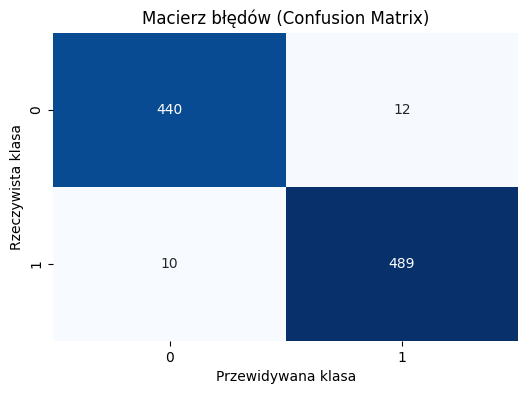

In [40]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz błędów (Confusion Matrix)')
plt.show()

## 4. Optymalizacja Hiperparametrów (Tuning)
Aby znaleźć najlepszy model, sprawdzamy zachowanie błędu treningowego i testowego oraz ogólnej skuteczności (accuracy) dla nieparzystych wartości $k$ z zakresu od 1 do 39.
Sprawdzimy również różne metryki odległości (Minkowskiego dla p=1 - odległość Manhattan, oraz p=2 - odległość Euklidesowa).

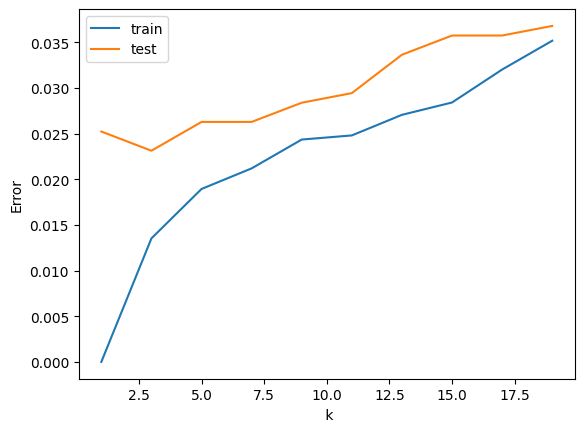

In [30]:
error1= []
error2= []
for k in range(1,21,2):
    knn=KNeighborsClassifier(k)
    knn.fit(x_train,y_train)
    y3=knn.predict(x_train)
    error1.append(np.mean(y_train != y3))
    y4=knn.predict(x_test)
    error2.append(np.mean(y_test != y4))

plt.plot(range(1,21,2), error1, label="train")
plt.plot(range(1,21,2), error2, label="test")
plt.xlabel(' k')
plt.ylabel('Error')
plt.legend()

In [31]:
accuracy_rate=[]

for i in range(1,41,2):
  knn=KNeighborsClassifier(i)
  knn.fit(x_train,y_train)
  y2=knn.predict(x_test)
  score=accuracy_score(y_test,y2)
  accuracy_rate.append(score)

In [32]:
accuracy_rate

[0.9747634069400631,
 0.9768664563617245,
 0.9737118822292324,
 0.9737118822292324,
 0.9716088328075709,
 0.9705573080967402,
 0.9663512092534174,
 0.964248159831756,
 0.964248159831756,
 0.9631966351209253,
 0.9631966351209253,
 0.9621451104100947,
 0.9589905362776026,
 0.9579390115667719,
 0.953732912723449,
 0.953732912723449,
 0.9547844374342797,
 0.9547844374342797,
 0.953732912723449,
 0.953732912723449]

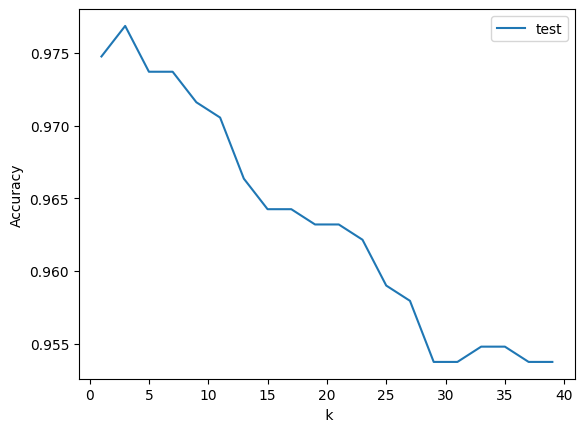

In [33]:
plt.plot(range(1,41,2), accuracy_rate, label="test")
plt.xlabel(' k')
plt.ylabel('Accuracy')
plt.legend()

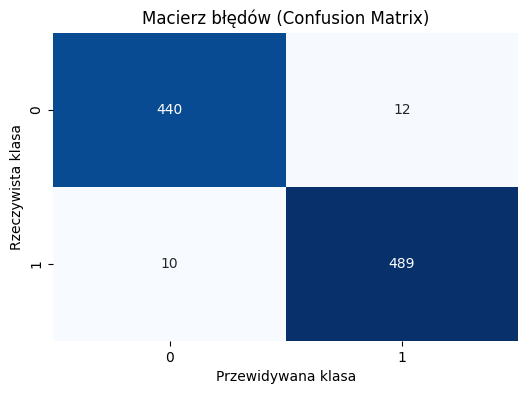

In [42]:
from sklearn.metrics import confusion_matrix
classifer = KNeighborsClassifier(n_neighbors=3)
classifer.fit(x_train,y_train)
y7=classifer.predict(x_test)
cm = confusion_matrix(y_test, y7)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz błędów (Confusion Matrix)')
plt.show()

In [35]:
accuracy_score(y_test, y7)

0.9768664563617245

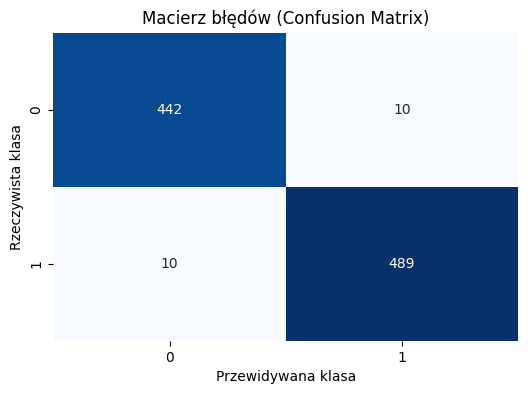

In [44]:
classiferm1 = KNeighborsClassifier(n_neighbors=3,metric="minkowski",p=1 )
classiferm1.fit(x_train,y_train)
y71=classiferm1.predict(x_test)
cm1 = confusion_matrix(y_test, y71)
plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz błędów (Confusion Matrix)')
plt.show()

In [37]:
accuracy_score(y_test, y71)

0.9789695057833859

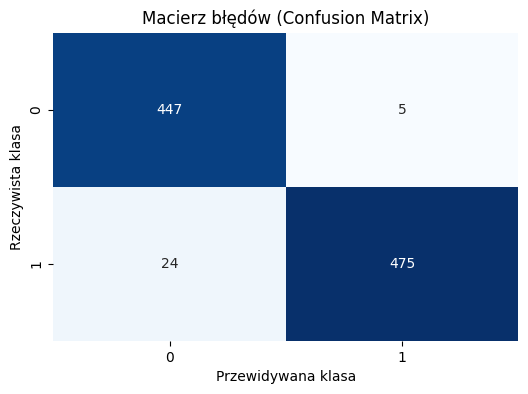

In [43]:
classiferm2 = KNeighborsClassifier(n_neighbors=2,metric="minkowski",p=2 )
classiferm2.fit(x_train,y_train)
y72=classiferm2.predict(x_test)
cm2 = confusion_matrix(y_test, y72)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz błędów (Confusion Matrix)')
plt.show()

In [39]:
accuracy_score(y_test, y72)

0.9695057833859095

## 5. Wnioski końcowe
* Skalowanie danych (StandardScaler) było kluczowe dla uzyskania wysokich wyników.
* Model osiąga znakomite wyniki klasyfikacji (około 97%).
* Zmiana metryki odległości na "Manhattan" (Minkowski, p=1) przy $k=3$ pozwoliła uzyskać najwyższą skuteczność wynoszącą **97.89%**.